# Normalización Práctica - Ecommify Olist Dataset

---

## Unidad 2: PostgreSQL - Diseño relacional avanzado

**Maestría en Arquitectura de Software**  
**Asignatura:** Diseño y Optimización de Bases de Datos  
**Universidad de La Sabana**

---

## Objetivos de aprendizaje

1. **Identificar** Identificar las claves primarias y foráneas
2. **Aplicar** progresivamente las formas normales (1FN, 2FN, 3FN) a datos reales
3. **Crear** diagramas entidad-relación (E-R) para visualizar el modelo normalizado
4. **Implementar** esquemas normalizados en PostgreSQL usando Supabase

---



## 1️. Configuración del entorno

### Instalación de librerías necesarias

Se instalarán las bibliotecas para análisis de datos, visualización y conexión a PostgreSQL.

In [71]:
# Instalación de librerías
!pip install pandas numpy matplotlib seaborn plotly psycopg2-binary sqlalchemy --quiet

print("Librerías instaladas correctamente")

Librerías instaladas correctamente


### Importación de bibliotecas

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
from sqlalchemy import create_engine, text
import psycopg2
from getpass import getpass

# Configuración de visualización
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Configuración de tamaños de figura por defecto
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Bibliotecas importadas exitosamente")
print(f"Versión de pandas: {pd.__version__}")
print(f"Versión de SQLAlchemy: {__import__('sqlalchemy').__version__}")

Bibliotecas importadas exitosamente
Versión de pandas: 2.2.2
Versión de SQLAlchemy: 2.0.49


---

## 2️. Conexión a Supabase (PostgreSQL)

### Configuración de credenciales


In [73]:
# Solicitar credenciales de forma segura
print("🔐 CONFIGURACIÓN DE CONEXIÓN A SUPABASE")
print("=" * 80)

# Solicitar el connection string completo
connection_string = getpass("Connection String: ")

# Validar que se ingresó un valor
if not connection_string or not connection_string.startswith('postgresql://'):
    print("❌ Error: Connection string inválido. Debe comenzar con 'postgresql://'")
else:
    print("\n Credenciales recibidas")
    print(" Probando conexión...\n")

🔐 CONFIGURACIÓN DE CONEXIÓN A SUPABASE
Connection String: ··········

 Credenciales recibidas
 Probando conexión...



### Probar conexión a Supabase

In [74]:
# Crear engine de SQLAlchemy
try:
    engine = create_engine(connection_string)

    # Probar conexión
    with engine.connect() as conn:
        result = conn.execute(text("SELECT version();"))
        version = result.fetchone()[0]

        print("CONEXIÓN EXITOSA A SUPABASE")
        print("=" * 80)
        print(f"\nVersión de PostgreSQL:")
        print(f"   {version.split(',')[0]}\n")

        # Obtener información del espacio disponible
        result = conn.execute(text("""
            SELECT pg_size_pretty(pg_database_size(current_database())) as db_size;
        """))
        db_size = result.fetchone()[0]
        print(f"Tamaño actual de la base de datos: {db_size}")
        print(f"Plan: Free Tier (500MB total)\n")

except Exception as e:
    print(f"❌ ERROR AL CONECTAR A SUPABASE")
    print(f"   {str(e)}")
    print("\nVerificar:")
    print("   1. Que el connection string esté completo y correcto")
    print("   2. Que la contraseña incluida sea la correcta")
    print("   3. Que el proyecto en Supabase esté activo")

CONEXIÓN EXITOSA A SUPABASE

Versión de PostgreSQL:
   PostgreSQL 17.6 on aarch64-unknown-linux-gnu

Tamaño actual de la base de datos: 165 MB
Plan: Free Tier (500MB total)



---

## 3. Carga del Dataset

Se cargará el dataset desde una fuente pública. Los archivos contienen información consolidada de customers, geolocation, order ítems, order payments, reviews, orders, products, sellers y category name.


In [75]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


### 3.1 Carga del Brazilian E-Commerce Olist Dataset

Enumerar los archivos CSV de la carpeta de Drive especificada directorio MyDrive/MaestríaArqSw/DiseñoOptimizacionBD/Dataset_BrazilianE

In [76]:
import os

drive_path = '/content/drive/MyDrive/MaestríaArqSw/DiseñoOptimizacionBD/Dataset_BrazilianE'

# Check archivos
if os.path.exists(drive_path):
    print(f"Listado de archivos: {drive_path}")
    csv_files = [f for f in os.listdir(drive_path) if f.endswith('.csv')]
    if csv_files:
        print("Archivos CSV encontrados:")
        for f in csv_files:
            print(f"- {f}")
    else:
        print("No se encntraron archivos CSV en este directorio.")
else:
    print(f"Error: Directorio no encontrado {drive_path}")
    csv_files = []

Listado de archivos: /content/drive/MyDrive/MaestríaArqSw/DiseñoOptimizacionBD/Dataset_BrazilianE
Archivos CSV encontrados:
- product_category_name_translation.csv
- olist_orders_dataset.csv
- olist_geolocation_dataset.csv
- olist_order_reviews_dataset.csv
- olist_products_dataset.csv
- olist_sellers_dataset.csv
- olist_customers_dataset.csv
- olist_order_payments_dataset.csv
- olist_order_items_dataset.csv


### Carga de Datasets Individuales

Vamos a cargar cada archivo CSV en un DataFrame de pandas y almacenarlos en un diccionario para fácil acceso. Luego, mostraremos información general sobre cada uno.

In [77]:
dataframes = {}

print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 80)

for csv_file_name in csv_files:
    file_path = os.path.join(drive_path, csv_file_name)
    print(f"\n--- Procesando archivo: {csv_file_name} ---")
    try:
        df_name = csv_file_name.replace('olist_', '').replace('_dataset.csv', '').replace('.csv', '')
        dataframes[df_name] = pd.read_csv(file_path)
        print(f"DataFrame '{df_name}' carga exitosa.")
        print(f"Filas: {len(dataframes[df_name]):,}, Columnas: {len(dataframes[df_name].columns)}")
        display(dataframes[df_name].head())
    except Exception as e:
        print(f"Error al cargar {csv_file_name}: {e}")


INFORMACIÓN GENERAL DEL DATASET

--- Procesando archivo: product_category_name_translation.csv ---
DataFrame 'product_category_name_translation' carga exitosa.
Filas: 71, Columnas: 2


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor



--- Procesando archivo: olist_orders_dataset.csv ---
DataFrame 'orders' carga exitosa.
Filas: 99,441, Columnas: 8


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



--- Procesando archivo: olist_geolocation_dataset.csv ---
DataFrame 'geolocation' carga exitosa.
Filas: 1,000,163, Columnas: 5


...

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



--- Procesando archivo: olist_order_payments_dataset.csv ---
DataFrame 'order_payments' carga exitosa.
Filas: 103,886, Columnas: 5


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45



--- Procesando archivo: olist_order_items_dataset.csv ---
DataFrame 'order_items' carga exitosa.
Filas: 112,650, Columnas: 7


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


### 3.2 Preparar tabla desnormalizada para análisis


Para preparar la tabla desnormalizada, uniremos los diferentes DataFrames utilizando las claves primarias y foráneas correspondientes. El objetivo es consolidar toda la información relevante de órdenes, clientes, productos, vendedores, etc., en una única tabla ancha.

In [78]:
# Realizar merges para crear la tabla desnormalizada

df_denormalized = dataframes['orders'].merge(dataframes['customers'], on='customer_id', how='left')
df_denormalized = df_denormalized.merge(dataframes['order_items'], on='order_id', how='left')
df_denormalized = df_denormalized.merge(dataframes['products'], on='product_id', how='left')
df_denormalized = df_denormalized.merge(dataframes['sellers'], on='seller_id', how='left')
df_denormalized = df_denormalized.merge(dataframes['order_payments'], on='order_id', how='left')
df_denormalized = df_denormalized.merge(dataframes['order_reviews'], on='order_id', how='left')

# Unir la traducción de nombres de categorías
df_denormalized = df_denormalized.merge(dataframes['product_category_name_translation'], on='product_category_name', how='left')

# La geolocalización es un dataset muy grande y se usa para otro tipo de análisis.
# Por lo tanto, no se fusionará directamente a nivel de transacción individual.

print("MUESTRA DE DATOS PARA ANÁLISIS DESNORMALIZADO")
print("=" * 80)

print(f"\nFilas seleccionadas: {len(df_denormalized):,}")
print(f"Columnas: {len(df_denormalized.columns)}\n")

# Mostrar primeras filas
print("\nPrimeras 3 filas de la tabla desnormalizada:\n")
display(df_denormalized.head(3))


MUESTRA DE DATOS PARA ANÁLISIS DESNORMALIZADO

Filas seleccionadas: 119,143
Columnas: 40


Primeras 3 filas de la tabla desnormalizada:



,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares


### 3.3 Crear tabla desnormalizada en Supabase

Crearemos la tabla `ecommify_olist_full` que contendrá todos los datos en una sola tabla desnormalizada.

In [79]:
def map_pandas_dtype_to_postgres(pandas_dtype):
    if 'int' in str(pandas_dtype):
        return 'INTEGER'
    elif 'float' in str(pandas_dtype):
        return 'NUMERIC'
    elif 'datetime' in str(pandas_dtype):
        return 'TIMESTAMP'
    elif 'bool' in str(pandas_dtype):
        return 'BOOLEAN'
    else:
        return 'TEXT'

# Generar el esquema de la tabla basado en df_denormalized
columns_sql = []
for col_name, dtype in df_denormalized.dtypes.items():
    pg_type = map_pandas_dtype_to_postgres(dtype)
    columns_sql.append(f'    "{col_name}" {pg_type}')

columns_definition = ",\n".join(columns_sql)

create_table_sql = f"""
CREATE TABLE ecommify_olist_full (
{columns_definition}
);
"""

print("Esquema SQL generado para la tabla ecommify_olist_full:\n")
print(create_table_sql)


Esquema SQL generado para la tabla ecommify_olist_full:


CREATE TABLE ecommify_olist_full (
    "order_id" TEXT,
    "customer_id" TEXT,
    "order_status" TEXT,
    "order_purchase_timestamp" TEXT,
    "order_approved_at" TEXT,
    "order_delivered_carrier_date" TEXT,
    "order_delivered_customer_date" TEXT,
    "order_estimated_delivery_date" TEXT,
    "customer_unique_id" TEXT,
    "customer_zip_code_prefix" INTEGER,
    "customer_city" TEXT,
    "customer_state" TEXT,
    "order_item_id" NUMERIC,
    "product_id" TEXT,
    "seller_id" TEXT,
    "shipping_limit_date" TEXT,
    "price" NUMERIC,
    "freight_value" NUMERIC,
    "product_category_name" TEXT,
    "product_name_lenght" NUMERIC,
    "product_description_lenght" NUMERIC,
    "product_photos_qty" NUMERIC,
    "product_weight_g" NUMERIC,
    "product_length_cm" NUMERIC,
    "product_height_cm" NUMERIC,
    "product_width_cm" NUMERIC,
    "seller_zip_code_prefix" NUMERIC,
    "seller_city" TEXT,
    "seller_state" TEXT,
   

In [80]:
# Helper to check if a table exists
def _table_exists(conn, table_name):
    result = conn.execute(text(f"SELECT EXISTS (SELECT 1 FROM information_schema.tables WHERE table_name = '{table_name}');"))
    return result.fetchone()[0]

table_name = 'ecommify_olist_full'

try:
    with engine.connect() as conn:
        if _table_exists(conn, table_name):
            print(f"Tabla '{table_name}' ya existe. No se eliminará ni se creará de nuevo.\n")
        else:
            # Crear tabla desnormalizada
            conn.execute(text(create_table_sql))
            conn.commit()
            print(f"Tabla '{table_name}' creada exitosamente\n")
except Exception as e:
    print(f"❌ Error al verificar o crear tabla: {e}")

Tabla 'ecommify_olist_full' ya existe. No se eliminará ni se creará de nuevo.



### 3.4 Insertar datos en la tabla `ecommify_olist_full`

Una vez creada la tabla, el siguiente paso es insertar los datos de nuestro DataFrame `df_denormalized` en la tabla de Supabase. Utilizaremos el método `to_sql` de pandas, asegurándonos de manejar los tipos de datos correctamente y en bloques para evitar problemas de memoria.

In [81]:
# Helper to check if a table has data
def _table_has_data(conn, table_name):
    result = conn.execute(text(f"SELECT COUNT(*) FROM {table_name};"))
    return result.fetchone()[0] > 0

print("INSERCIÓN DE DATOS EN SUPABASE")
print("=" * 80)

table_name = 'ecommify_olist_full'

try:
    with engine.connect() as conn:
        if _table_has_data(conn, table_name):
            print(f"La tabla '{table_name}' ya contiene datos. No se insertarán nuevos datos para optimizar el proceso.")
        else:
            # Usar to_sql para insertar el DataFrame en la tabla de PostgreSQL
            df_denormalized.to_sql(table_name, engine, if_exists='append', index=False, chunksize=1000)

            print(f"\nDATOS CARGADOS EXITOSAMENTE '{table_name}' en Supabase.")

            # Opcional: Verificar el número de filas insertadas
            result = conn.execute(text(f"SELECT COUNT(*) FROM {table_name};"))
            row_count = result.fetchone()[0]
            print(f"Registros insertados: {row_count:,}")

            result2 = conn.execute(text(f"SELECT pg_size_pretty(pg_table_size('{table_name}'));"))
            table_size = result2.fetchone()[0]
            print(f"Tamaño de la tabla '{table_name}': {table_size}")

except Exception as e:
    print(f"❌ Error al insertar datos en la tabla: {e}")
    print("\nVerificar:")
    print("   - Conexión a la base de datos esté activa.")

INSERCIÓN DE DATOS EN SUPABASE
La tabla 'ecommify_olist_full' ya contiene datos. No se insertarán nuevos datos para optimizar el proceso.


---

## 4. Aplicación de formas normales

### 4.1 Primera Forma Normal (1FN)

**Requisitos de 1FN:**
1. Todos los atributos deben contener valores atómicos (indivisibles)
2. No debe haber grupos repetitivos de columnas
3. Cada fila debe ser única
4. El orden de las filas no debe importar

### 4.1.1 Verificación y Aplicación de 1FN

En la tabla desnormalizada, varios campos de fecha y hora están actualmente como tipo `object` (string). Para cumplir con la 1FN, estos deben ser valores atómicos de fecha y hora. Esto permitirá realizar operaciones temporales adecuadas y asegurar la integridad de los datos.

**Acción:** Convertir las columnas de fecha y hora a tipo `datetime`.

In [82]:
print("VERIFICACIÓN DE PRIMERA FORMA NORMAL (1FN)")
print("=" * 80)

# Identificar columnas que deberían ser de tipo datetime
datetime_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'shipping_limit_date',
    'review_creation_date',
    'review_answer_timestamp'
]

print("\nAntes de la conversión de tipos de datos:")
for col in datetime_cols:
    print(f"  - '{col}': {df_denormalized[col].dtype}")

# Convertir las columnas a tipo datetime
for col in datetime_cols:
    df_denormalized[col] = pd.to_datetime(df_denormalized[col], errors='coerce')

print("\nDespués de la conversión de tipos de datos:")
for col in datetime_cols:
    print(f"  - '{col}': {df_denormalized[col].dtype}")

print("\n--- Verificación de valores nulos después de la conversión ---")
for col in datetime_cols:
    if df_denormalized[col].isnull().any():
        print(f"  - '{col}': {df_denormalized[col].isnull().sum()} valores nulos (posibles errores en los datos originales)")


print("\nLa tabla 'df_denormalized' cumple ahora los requisitos de la Primera Forma Normal en cuanto a la atomicidad de los campos temporales y la estructura general.")


VERIFICACIÓN DE PRIMERA FORMA NORMAL (1FN)

Antes de la conversión de tipos de datos:
  - 'order_purchase_timestamp': object
  - 'order_approved_at': object
  - 'order_delivered_carrier_date': object
  - 'order_delivered_customer_date': object
  - 'order_estimated_delivery_date': object
  - 'shipping_limit_date': object
  - 'review_creation_date': object
  - 'review_answer_timestamp': object

Después de la conversión de tipos de datos:
  - 'order_purchase_timestamp': datetime64[ns]
  - 'order_approved_at': datetime64[ns]
  - 'order_delivered_carrier_date': datetime64[ns]
  - 'order_delivered_customer_date': datetime64[ns]
  - 'order_estimated_delivery_date': datetime64[ns]
  - 'shipping_limit_date': datetime64[ns]
  - 'review_creation_date': datetime64[ns]
  - 'review_answer_timestamp': datetime64[ns]

--- Verificación de valores nulos después de la conversión ---
  - 'order_approved_at': 177 valores nulos (posibles errores en los datos originales)
  - 'order_delivered_carrier_date': 2

### 4.2 Segunda Forma Normal (2FN)

**Requisitos de 2FN:**
1. Debe estar en 1FN
2. Todos los atributos no-clave deben depender de la clave primaria completa
3. No debe haber dependencias parciales (relevante solo para claves compuestas)

**Análisis de dependencias funcionales:**

### 4.2.1 Descomposición del DataFrame `df_denormalized` para 2FN

las siguientes entidades con sus atributos clave seran nuevas tablas normalizadas. Para cada tabla, se tomaron las columnas relevantes del `df_denormalized` y eliminando duplicados para obtener registros únicos para cada entidad.

---

#### Tabla `customers`

**Clave Primaria:** `customer_id`

**Atributos:** `customer_unique_id`, `customer_zip_code_prefix`, `customer_city`, `customer_state`

In [83]:
df_customers = df_denormalized[['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']].drop_duplicates().reset_index(drop=True)
print(f"Customers (Filas: {len(df_customers):,}, Columnas: {len(df_customers.columns)})\n")
display(df_customers.head())


Customers (Filas: 99,441, Columnas: 5)



,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


#### Tabla `orders`

**Clave Primaria:** `order_id`

**Clave Foránea:** `customer_id`

**Atributos:** `order_status`, `order_purchase_timestamp`, `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`, `order_estimated_delivery_date`

In [84]:
df_orders = df_denormalized[[ 'order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']].drop_duplicates().reset_index(drop=True)
print(f"Orders (Filas: {len(df_orders):,}, Columnas: {len(df_orders.columns)})\n")
display(df_orders.head())


Orders (Filas: 99,441, Columnas: 8)



,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


#### Tabla `order_items`

**Clave Primaria Compuesta:** `order_id`, `order_item_id`

**Clave Foránea:** `product_id`, `seller_id`

**Atributos:** `shipping_limit_date`, `price`, `freight_value`

In [85]:
df_order_items = df_denormalized[[ 'order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']].drop_duplicates().reset_index(drop=True)
print(f"Order Items (Filas: {len(df_order_items):,}, Columnas: {len(df_order_items.columns)})\n")
display(df_order_items.head())


Order Items (Filas: 113,425, Columnas: 7)



,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


In [86]:
print("\n--- Verificando valores nulos en df_order_items antes de la inserción ---")
display(df_order_items.isnull().sum())

# Filtrar filas donde 'order_item_id' es nulo, ya que es parte de la clave primaria compuesta
initial_rows_order_items = len(df_order_items)
df_order_items.dropna(subset=['order_item_id'], inplace=True)
rows_dropped_order_items = initial_rows_order_items - len(df_order_items)

if rows_dropped_order_items > 0:
    print(f"Advertencia: Se eliminaron {rows_dropped_order_items} filas de 'df_order_items' debido a valores nulos en 'order_item_id'.")

print("\n--- Verificando valores nulos después de eliminar filas con NaN en 'order_item_id' ---")
display(df_order_items.isnull().sum())


--- Verificando valores nulos en df_order_items antes de la inserción ---


,0
order_id,0
order_item_id,775
product_id,775
seller_id,775
shipping_limit_date,775
price,775
freight_value,775


Advertencia: Se eliminaron 775 filas de 'df_order_items' debido a valores nulos en 'order_item_id'.

--- Verificando valores nulos después de eliminar filas con NaN en 'order_item_id' ---


,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


#### Tabla order_payments

**Clave Primaria Compuesta:** order_id, payment_sequential

**Clave Foránea: order_id**

**Atributos:** payment_type, payment_installments, payment_value

In [87]:
df_order_payments = df_denormalized[[ 'order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']].drop_duplicates().reset_index(drop=True)
print(f"Payments (Filas: {len(df_order_payments):,}, Columnas: {len(df_order_payments.columns)})\n")
display(df_order_payments.head())


Payments (Filas: 103,887, Columnas: 5)



,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,1.0,credit_card,3.0,179.12


In [88]:
print("\n--- Verificando valores nulos en df_order_payments antes de la inserción ---")
display(df_order_payments.isnull().sum())

# Filtrar filas donde 'order_id' o 'payment_sequential' son nulos, ya que son parte de la clave primaria compuesta
initial_rows_payments = len(df_order_payments)
df_order_payments.dropna(subset=['order_id', 'payment_sequential'], inplace=True)
rows_dropped_payments = initial_rows_payments - len(df_order_payments)

if rows_dropped_payments > 0:
    print(f"Advertencia: Se eliminaron {rows_dropped_payments} filas de 'df_order_payments' debido a valores nulos en sus claves primarias.")

print("\n--- Verificando valores nulos después de eliminar filas con NaN en claves primarias ---")
display(df_order_payments.isnull().sum())


--- Verificando valores nulos en df_order_payments antes de la inserción ---


,0
order_id,0
payment_sequential,1
payment_type,1
payment_installments,1
payment_value,1


Advertencia: Se eliminaron 1 filas de 'df_order_payments' debido a valores nulos en sus claves primarias.

--- Verificando valores nulos después de eliminar filas con NaN en claves primarias ---


,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


#### Tabla sellers

**Clave Primaria Compuesta:** seller_id

**Atributos:** seller_zip_code_prefix, seller_city, seller_state

In [89]:
df_seller = df_denormalized[[ 'seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']].drop_duplicates().reset_index(drop=True)
print(f"Selers (Filas: {len(df_seller):,}, Columnas: {len(df_seller.columns)})\n")
display(df_seller.head())

Selers (Filas: 3,096, Columnas: 4)



,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3504c0cb71d7fa48d967e0e4c94d59d9,9350.0,maua,SP
1,289cdb325fb7e7f891c38608bf9e0962,31570.0,belo horizonte,SP
2,4869f7a5dfa277a7dca6462dcf3b52b2,14840.0,guariba,SP
3,66922902710d126a0e7d26b0e3805106,31842.0,belo horizonte,MG
4,2c9e548be18521d1c43cde1c582c6de8,8752.0,mogi das cruzes,SP


### 4.3 Exclusión de Tablas No Transaccionales para 2FN en Supabase:

En esta etapa, el proceso de normalización se enfoca exclusivamente en las tablas transaccionales que se beneficiarán más de un esquema relacional en PostgreSQL. Las tablas que consideramos candidatas para Bases de Datos No Relacionales (como MongoDB) debido a su naturaleza menos transaccional o a la complejidad de sus atributos serán excluidas de este proceso de carga en Supabase.

**Tablas incluidas (transaccionales, se mantienen en PostgreSQL):**
*   `customers`
*   `orders`
*   `order_items`
*   `order_payments`
*   `sellers`

**Tablas excluidas (no transaccionales, candidatas para NoSQL):**
*   `products`: Contiene el catálogo de productos. Sus atributos pueden ser complejos y variar, lo que se adapta bien a un esquema flexible de NoSQL.
*   `reviews`: Contiene las valoraciones y comentarios de los clientes. El contenido de texto libre y la estructura flexible de los comentarios son ideales para NoSQL.
*   `product_categories`: Contiene la jerarquía y traducción de categorías de productos. Puede ser mejor manejado en NoSQL si la estructura de categorías es dinámica o anidada.
*   `geolocation`: Contiene información de ubicación asociada a código postal. No se relaciona directamente uno a uno a cada pedido, se usa como referencia para análisis logístico y geográfico. En olist puede haber varios registros por el mismo prefijo postal.          

### 4.4 Tercera Forma Normal (3FN)

**Requisitos de 3FN:**
1.  Debe estar en 2FN.
2.  No debe haber dependencias transitivas (atributos no clave que dependen de otros atributos no clave).

Al analizar las tablas `customers`, `orders`, `order_items`, `sellers` y `order_payments` después de aplicar 2FN, se ha determinado que estas tablas ya cumplen con los requisitos de 3FN. Cada atributo no clave depende directamente de la clave primaria (o claves primarias compuestas) y no existen dependencias transitivas donde un atributo no clave determine el valor de otro atributo no clave.

Por ejemplo:
*   En `customers`, `customer_unique_id`, `customer_zip_code_prefix`, `customer_city`, `customer_state` dependen directamente de `customer_id`.
*   En `orders`, todos los atributos relacionados con la orden dependen de `order_id`.
*   En `order_items`, `shipping_limit_date`, `price`, `freight_value` dependen de la clave compuesta (`order_id`, `order_item_id`).
*   En `order_payments`, `payment_type`, `payment_installments`, `payment_value` dependen de la clave compuesta (`order_id`, `payment_sequential`).
*   En `sellers`, `seller_zip_code_prefix`, `seller_city`, `seller_state` dependen directamente de `seller_id`.

Por lo tanto, las tablas transaccionales seleccionadas están completamente normalizadas a 3FN en este punto.

In [94]:
def create_and_insert_table(df, table_name, pk_columns, uuid_cols=None):
    if uuid_cols is None:
        uuid_cols = []

    print(f"\n--- Procesando tabla: {table_name} ---")

    # Generar el esquema de la tabla basado en el DataFrame
    columns_sql = []
    for col_name, dtype in df.dtypes.items():
        if col_name in uuid_cols:
            pg_type = 'UUID'
        else:
            pg_type = map_pandas_dtype_to_postgres(dtype)
        columns_sql.append(f'    "' + col_name + '" ' + pg_type)

    # Añadir PRIMARY KEY si se especifica
    if pk_columns:
        if isinstance(pk_columns, list):
            pk_definition = ", ".join([f'"' + col + '"' for col in pk_columns])
            columns_sql.append(f'    PRIMARY KEY (' + pk_definition + ')')
        else:
            columns_sql.append(f'    PRIMARY KEY ("' + pk_columns + '")')

    # FIX: Ensure commas separate column definitions in SQL CREATE TABLE statement
    columns_definition = ",\n".join(columns_sql)
    create_table_sql = f"""
CREATE TABLE {table_name} (
{columns_definition}
);
"""

    # Eliminar tabla si existe (para poder re-ejecutar el notebook)
    try:
        with engine.connect() as conn:
            conn.execute(text(f"DROP TABLE IF EXISTS {table_name} CASCADE;"))
            conn.commit()
            print(f"Tabla '{table_name}' anterior eliminada (si existía).")
    except Exception as e:
        print(f"⚠️ Advertencia al eliminar '{table_name}': {type(e).__name__} - {str(e)[:200]}")

    # Crear tabla
    try:
        with engine.connect() as conn:
            conn.execute(text(create_table_sql))
            conn.commit()
            print(f"Tabla '{table_name}' creada exitosamente.")
    except Exception as e:
        print(f"❌ Error al crear tabla '{table_name}': {type(e).__name__} - {str(e)[:200]}")
        print(f"SQL para crear tabla: {create_table_sql}")
        return

    # Insertar datos
    try:
        df.to_sql(table_name, engine, if_exists='append', index=False, chunksize=1000)
        with engine.connect() as conn:
            result = conn.execute(text(f"SELECT COUNT(*) FROM {table_name};"))
            row_count = result.fetchone()[0]
            print(f"Datos insertados exitosamente en '{table_name}'. Registros: {row_count:,}")
            result_size = conn.execute(text(f"SELECT pg_size_pretty(pg_table_size('{table_name}'));"))
            table_size = result_size.fetchone()[0]
            print(f"Tamaño de la tabla '{table_name}': {table_size}")
    except Exception as e:
        print(f"❌ Error al insertar datos en '{table_name}': {type(e).__name__} - {str(e)[:500]}")

# --- Ejecutar para cada tabla normalizada transaccional ---

try:
    # Ensure df_customers is clean before insertion
    df_customers.dropna(subset=['customer_id'], inplace=True)
    create_and_insert_table(df_customers, 'customers', 'customer_id', uuid_cols=['customer_id'])
except Exception as e:
    print(f"❌ Error general al procesar 'customers': {type(e).__name__} - {str(e)[:500]}")

try:
    # Ensure df_orders is clean before insertion
    df_orders.dropna(subset=['order_id'], inplace=True)
    df_orders.drop_duplicates(subset=['order_id'], keep='first', inplace=True)
    # Fill NaT values in datetime columns with None to allow NULL in PostgreSQL
    df_orders['order_approved_at'] = df_orders['order_approved_at'].apply(lambda x: None if pd.isna(x) else x)
    df_orders['order_delivered_carrier_date'] = df_orders['order_delivered_carrier_date'].apply(lambda x: None if pd.isna(x) else x)
    df_orders['order_delivered_customer_date'] = df_orders['order_delivered_customer_date'].apply(lambda x: None if pd.isna(x) else x)
    create_and_insert_table(df_orders, 'orders', 'order_id', uuid_cols=['order_id', 'customer_id'])
except Exception as e:
    print(f"❌ Error general al procesar 'orders': {type(e).__name__} - {str(e)[:500]}")

try:
    # Ensure df_order_items is clean before insertion
    df_order_items.dropna(subset=['order_id', 'order_item_id'], inplace=True)
    df_order_items.drop_duplicates(subset=['order_id', 'order_item_id'], keep='first', inplace=True)
    # Convert 'order_item_id' to integer after dropping NaNs if it can be represented as int
    if 'order_item_id' in df_order_items.columns and df_order_items['order_item_id'].dtype == 'float64':
        if (df_order_items['order_item_id'] == df_order_items['order_item_id'].astype(int)).all():
            df_order_items['order_item_id'] = df_order_items['order_item_id'].astype(int)
    create_and_insert_table(df_order_items, 'order_items', ['order_id', 'order_item_id'], uuid_cols=['order_id', 'product_id', 'seller_id'])
except Exception as e:
    print(f"❌ Error general al procesar 'order_items': {type(e).__name__} - {str(e)[:500]}")

try:
    # Ensure df_payments is clean before insertion
    df_order_payments.dropna(subset=['order_id', 'payment_sequential'], inplace=True)
    create_and_insert_table(df_order_payments, 'order_payments', ['order_id', 'payment_sequential'], uuid_cols=['order_id'])
except Exception as e:
    print(f"❌ Error general al procesar 'payments': {type(e).__name__} - {str(e)[:500]}")

try:
    # Ensure df_seller is clean before insertion
    df_seller.dropna(subset=['seller_id'], inplace=True)
    df_seller.drop_duplicates(subset=['seller_id'], keep='first', inplace=True)
    create_and_insert_table(df_seller, 'sellers', 'seller_id', uuid_cols=['seller_id'])
except Exception as e:
    print(f"❌ Error general al procesar 'sellers': {type(e).__name__} - {str(e)[:500]}")


--- Procesando tabla: customers ---
Tabla 'customers' anterior eliminada (si existía).
Tabla 'customers' creada exitosamente.
Datos insertados exitosamente en 'customers'. Registros: 99,441
Tamaño de la tabla 'customers': 10048 kB

--- Procesando tabla: orders ---
Tabla 'orders' anterior eliminada (si existía).
Tabla 'orders' creada exitosamente.
Datos insertados exitosamente en 'orders'. Registros: 99,441
Tamaño de la tabla 'orders': 11 MB

--- Procesando tabla: order_items ---
Tabla 'order_items' anterior eliminada (si existía).
Tabla 'order_items' creada exitosamente.
Datos insertados exitosamente en 'order_items'. Registros: 112,650
Tamaño de la tabla 'order_items': 12 MB

--- Procesando tabla: order_payments ---
Tabla 'order_payments' anterior eliminada (si existía).
Tabla 'order_payments' creada exitosamente.
Datos insertados exitosamente en 'order_payments'. Registros: 103,886
Tamaño de la tabla 'order_payments': 7632 kB

--- Procesando tabla: sellers ---
Tabla 'sellers' anteri

---

## 5. Visualización: Diagrama Entidad-Relación

### 5.1 Diagrama E-R del modelo normalizado

Crearemos una representación visual del modelo de datos normalizado:

```mermaid
erDiagram
    customers ||--o{ orders : customer_id
    orders ||--o{ order_items : order_id
    orders ||--o{ order_payments : order_id
    sellers ||--o{ order_items : seller_id

    customers {
        UUID customer_id PK
        VARCHAR customer_unique_id
        INTEGER customer_zip_code_prefix
        VARCHAR customer_city
        VARCHAR customer_state
    }
    orders {
        UUID order_id PK
        UUID customer_id FK
        VARCHAR order_status
        DATETIME order_purchase_timestamp
        DATETIME order_approved_at
        DATETIME order_delivered_carrier_date
        DATETIME order_delivered_customer_date
        DATETIME order_estimated_delivery_date
    }
    order_items {
        UUID order_id PK,FK
        INTEGER order_item_id PK
        UUID product_id FK
        UUID seller_id FK
        DATETIME shipping_limit_date
        NUMERIC price
        NUMERIC freight_value
    }
    order_payments {
        UUID order_id PK,FK
        INTEGER payment_sequential PK
        VARCHAR payment_type
        NUMERIC payment_installments
        NUMERIC payment_value
    }
    sellers {
        UUID seller_id PK
        INTEGER seller_zip_code_prefix
        VARCHAR seller_city
        VARCHAR seller_state
    }
```

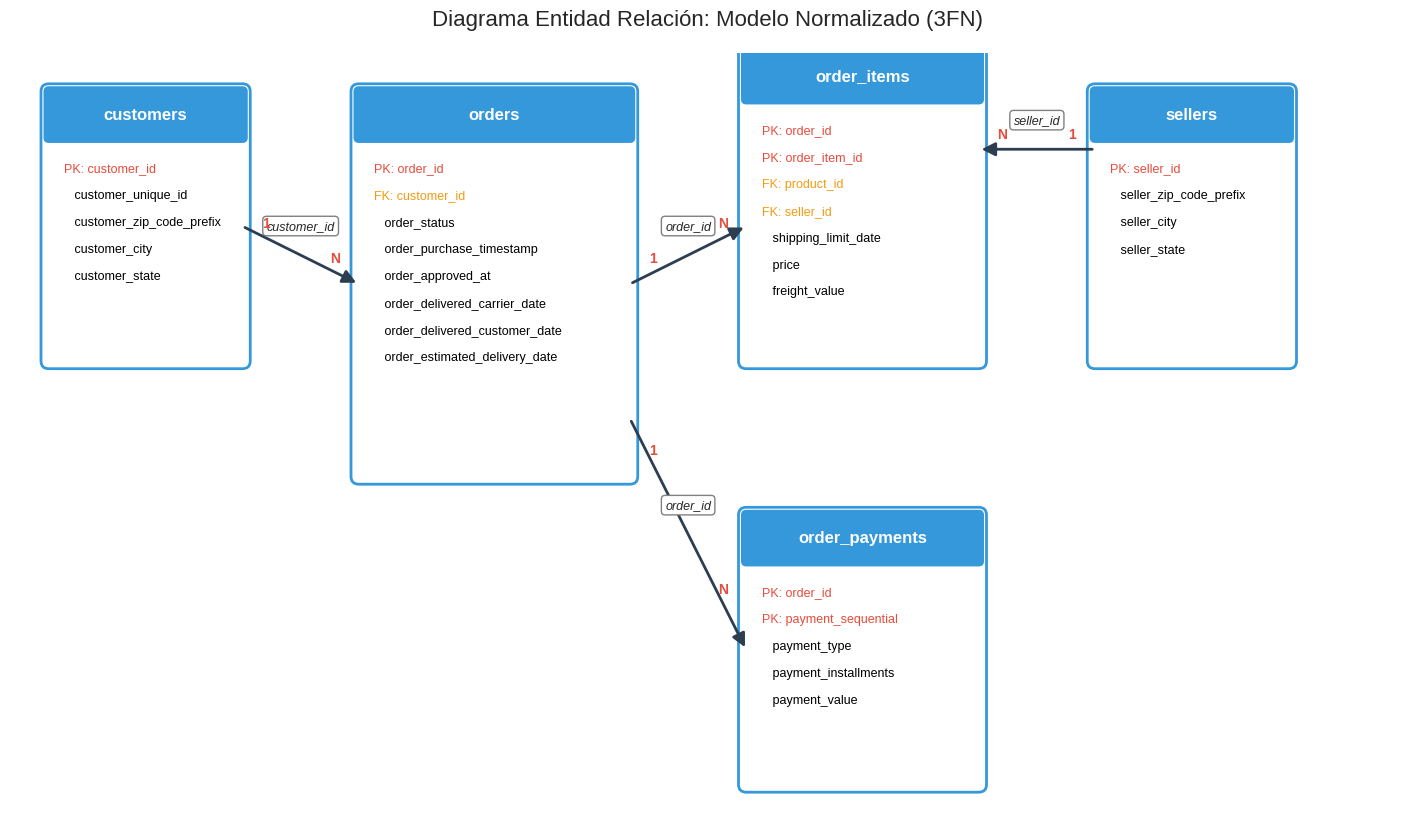

In [93]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(18, 10)) # Increased figsize width
ax.set_xlim(0, 18) # Increased xlim to accommodate the sellers table
ax.set_ylim(0, 10)
ax.axis('off')

# Colors
color_entity = '#3498db'
color_pk = '#e74c3c'
color_fk = '#f39c12'
color_attr = '#ecf0f1'

def draw_entity(ax, x, y, width, height, title, attributes, pk_attrs, fk_attrs=[]):
    """Dibuja una entidad en el diagrama E-R"""
    # Caja principal
    box = FancyBboxPatch((x, y), width, height,
                          boxstyle="round,pad=0.1",
                          edgecolor=color_entity,
                          facecolor='white',
                          linewidth=2)
    ax.add_patch(box)

    # Título
    title_box = FancyBboxPatch((x, y + height - 0.6), width, 0.6,
                                boxstyle="round,pad=0.05",
                                edgecolor=color_entity,
                                facecolor=color_entity,
                                linewidth=2)
    ax.add_patch(title_box)
    ax.text(x + width/2, y + height - 0.3, title,
            ha='center', va='center', fontsize=12, fontweight='bold', color='white')

    # Atributos
    y_attr = y + height - 1.0
    for i, attr in enumerate(attributes):
        if attr in pk_attrs:
            color = color_pk
            prefix = "PK: "
        elif attr in fk_attrs:
            color = color_fk
            prefix = "FK: "
        else:
            color = 'black'
            prefix = "   "

        ax.text(x + 0.2, y_attr - i*0.35, f"{prefix}{attr}",
                ha='left', va='center', fontsize=9, color=color)

def draw_relationship(ax, x1, y1, x2, y2, label, card1="N", card2="1"):
    """Dibuja una relación entre entidades"""
    arrow = FancyArrowPatch((x1, y1), (x2, y2),
                           arrowstyle='-|>',
                           mutation_scale=20,
                           linewidth=2,
                           color='#2c3e50')
    ax.add_patch(arrow)

    # Etiquetas de cardinalidad
    mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2
    ax.text(mid_x, mid_y + 0.3, label, ha='center', va='bottom',
            fontsize=9, style='italic',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray'))

    # Calculate positions for cardinalities along the line
    card1_x = x1 + (x2 - x1) * 0.20 # 20% along the line from x1
    card1_y = y1 + (y2 - y1) * 0.20 # 20% along the line from y1
    card2_x = x2 - (x2 - x1) * 0.20 # 20% along the line from x2 back towards x1
    card2_y = y2 - (y2 - y1) * 0.20 # 20% along the line from y2 back towards y1

    # Small vertical offset to move it slightly above the line
    vertical_offset = 0.1

    ax.text(card1_x, card1_y + vertical_offset, card1, ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='#e74c3c', rotation_mode='anchor')
    ax.text(card2_x, card2_y + vertical_offset, card2, ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='#e74c3c', rotation_mode='anchor')

# --- Dibujar entidades ---

# Customers
cust_attrs = [
    'customer_id',
    'customer_unique_id',
    'customer_zip_code_prefix',
    'customer_city',
    'customer_state'
]
draw_entity(ax, 0.5, 6, 2.5, 3.5, 'customers', cust_attrs, pk_attrs=['customer_id'])

# Orders
ord_attrs = [
    'order_id',
    'customer_id',
    'order_status',
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
draw_entity(ax, 4.5, 4.5, 3.5, 5, 'orders', ord_attrs, pk_attrs=['order_id'], fk_attrs=['customer_id'])

# Order Items
oitem_attrs = [
    'order_id',
    'order_item_id',
    'product_id',
    'seller_id',
    'shipping_limit_date',
    'price',
    'freight_value'
]
draw_entity(ax, 9.5, 6, 3, 4, 'order_items', oitem_attrs, pk_attrs=['order_id', 'order_item_id'], fk_attrs=['order_id', 'product_id', 'seller_id'])

# Payments
pay_attrs = [
    'order_id',
    'payment_sequential',
    'payment_type',
    'payment_installments',
    'payment_value'
]
draw_entity(ax, 9.5, 0.5, 3, 3.5, 'order_payments', pay_attrs, pk_attrs=['order_id', 'payment_sequential'], fk_attrs=['order_id']) # Changed 'payments' to 'order_payments'

# Sellers
seller_attrs = [
    'seller_id',
    'seller_zip_code_prefix',
    'seller_city',
    'seller_state'
]
draw_entity(ax, 14.0, 6.0, 2.5, 3.5, 'sellers', seller_attrs, pk_attrs=['seller_id'])


# --- Dibujar relaciones ---

# customers -- orders
draw_relationship(ax, 3, 7.75, 4.5, 7, 'customer_id', card1='1', card2='N')

# orders -- order_items
draw_relationship(ax, 8, 7, 9.5, 7.75, 'order_id', card1='1', card2='N')

# orders -- payments
draw_relationship(ax, 8, 5.25, 9.5, 2.25, 'order_id', card1='1', card2='N')

# sellers -- order_items (moved to be higher and more to the right)
draw_relationship(ax, 14.0, 8.75, 12.5, 8.75, 'seller_id', card1='1', card2='N')

plt.title('Diagrama Entidad Relación: Modelo Normalizado (3FN)', fontsize=16, pad=20)
plt.show()